<a href="https://colab.research.google.com/github/DiFedorchuk/ML_Course/blob/main/HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
raw_df = pd.read_csv('/content/drive/MyDrive/Courses/Machine Learning/Data/tweet_sentiment_train.csv.zip')

In [5]:
raw_df.head(5)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [7]:
raw_df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [8]:
df = raw_df.dropna().copy()
print("DataFrame after dropping null values:")
df.info()

DataFrame after dropping null values:
<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
dtypes: object(4)
memory usage: 1.0+ MB


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [10]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


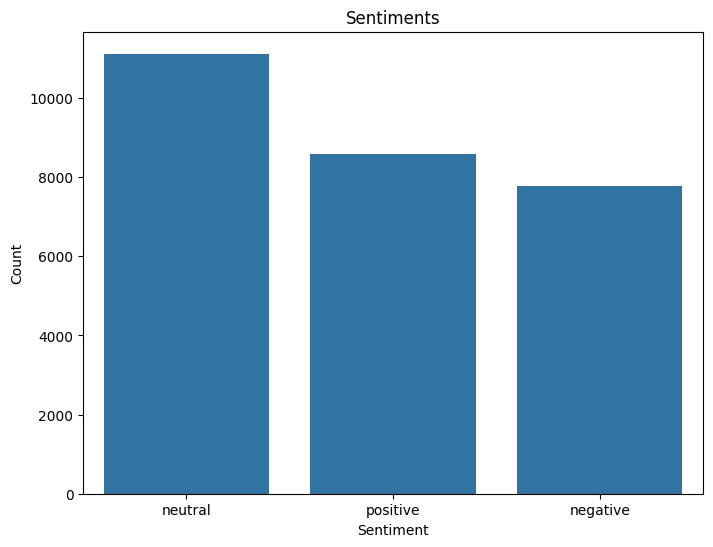

In [11]:
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

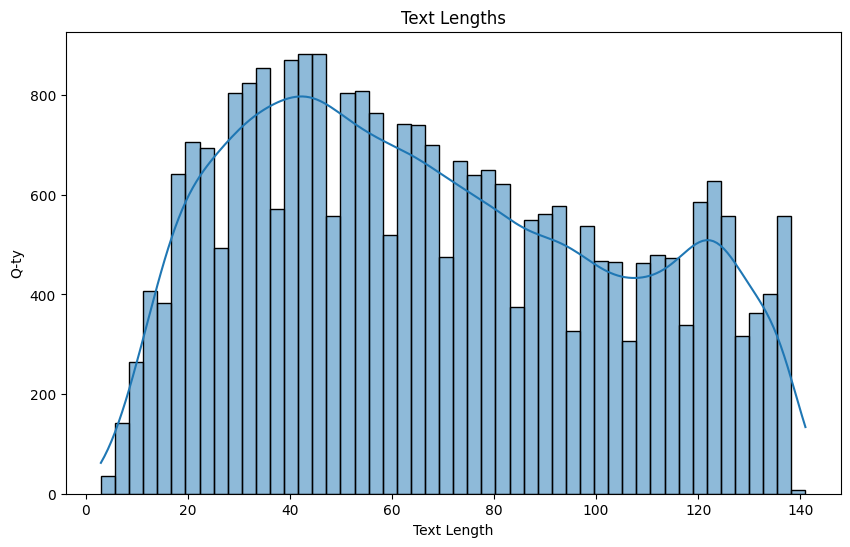

count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_length, dtype: float64


In [ ]:
df['text_length'] = df['text'].astype(str).apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Q-ty')
plt.show()

print(df['text_length'].describe())

In [ ]:
most_common_lengths = df['text_length'].value_counts().head(5)
print(most_common_lengths)

text_length
41    308
48    301
46    301
42    298
45    295
Name: count, dtype: int64


Датасет містить тексти в середньому по 68 символів. Довжина текстів різна від 3 до 141 символів. З візуалізації бачимо трохи правоскошений розподіл, що показує що більшість текстів є короткими. Найчастіше зустрічаються тексти які містять  41 символ. Більшість текстів відносяться до нейтрального класу, до негативного відносяться найменше текстів

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [25]:
import nltk
nltk.download('punkt_tab')
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [35]:
nltk.download('stopwords')
stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()  # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text) # keep only letters and spaces
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)
df_vect = CountVectorizer(max_features= 10000)
X_bag = df_vect.fit_transform(df['processed_text'])

print("Shape of vectorized data):", X_bag.shape)
df_vect.get_feature_names_out()[9000:9010]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Shape of vectorized data): (27480, 10000)


array(['tissu', 'tita', 'titan', 'titl', 'tivo', 'tix', 'tm', 'tminus',
       'tmobil', 'tmr'], dtype=object)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [36]:
from sklearn.model_selection import train_test_split
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bag, df['sentiment'],
                                                                        test_size=0.3, random_state=42)
print("Shape of X_train_bow:", X_train_bow.shape)
print("Shape of X_test_bow:", X_test_bow.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train_bow: (19236, 10000)
Shape of X_test_bow: (8244, 10000)
Shape of y_train: (19236,)
Shape of y_test: (8244,)


In [37]:
from sklearn.linear_model import LogisticRegression
MAX_ITER = 1000

In [38]:
model = LogisticRegression(max_iter=MAX_ITER, solver='sag')

In [39]:
%%time
model.fit(X_train_bow, y_train)

CPU times: user 1.72 s, sys: 4.62 ms, total: 1.73 s
Wall time: 2.85 s


LogisticRegression(max_iter=1000, solver='sag')

In [41]:
train_preds = model.predict(X_train_bow)

In [43]:
pd.Series(train_preds).value_counts()

,count
neutral,8441
positive,5832
negative,4963


In [45]:
pd.Series(y_train).value_counts()

,count
sentiment,
neutral,7774
positive,6037
negative,5425


In [50]:
from sklearn.metrics import accuracy_score, f1_score
accuracy_score(y_train, train_preds)

0.8563630692451654

In [51]:
f1_score(y_train, train_preds, average='weighted')

0.8564366515766114

In [59]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xgboost_model = XGBClassifier(objective='multi:softmax',
                            num_class=len(label_encoder.classes_),
                            eval_metric='mlogloss',
                            use_label_encoder=False,
                            random_state=42)

xgboost_model.fit(X_train_bow, y_train_encoded)
xgboost_train_preds = xgboost_model.predict(X_train_bow)

print("XGBoost Training Accuracy:", accuracy_score(y_train_encoded, xgboost_train_preds))
print("XGBoost Training F1-score (weighted):", f1_score(y_train_encoded, xgboost_train_preds, average='weighted'))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:49:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Training Accuracy: 0.746153046371387
XGBoost Training F1-score (weighted): 0.7447974204734883


In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_bow, y_train_encoded)
decision_tree_train_preds = decision_tree_model.predict(X_train_bow)

print("Decision Tree Training Accuracy:", accuracy_score(y_train_encoded, decision_tree_train_preds))
print("Decision Tree Training F1-score (weighted):", f1_score(y_train_encoded, decision_tree_train_preds, average='weighted'))

Decision Tree Training Accuracy: 0.9954252443335413
Decision Tree Training F1-score (weighted): 0.9954261322359998


Після тренуваття XGBoost, Logistic Regression, Decision Trees, можна сказати що найкращий результат показує Logistic Regression з F1 0,87, XGBoost показав гіршй результат F1 0,74, можливо потрібно додатково оптимізовувати параметри, Decision Trees явно заоверфітився з результатом F1 0,99

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [62]:
feature_names = df_vect.get_feature_names_out()
coefs = model.coef_
classes = model.classes_

print("\nFeature Importance Analysis for Logistic Regression:\n")

for i, class_label in enumerate(classes):
    class_coefs = coefs[i]

    # Sort features by coefficient value for this class
    sorted_coef_indices = class_coefs.argsort()

    # Top positive features
    top_positive_features = [feature_names[j] for j in sorted_coef_indices[-10:]]
    top_positive_values = [class_coefs[j] for j in sorted_coef_indices[-10:]]

    # Top negative features
    top_negative_features = [feature_names[j] for j in sorted_coef_indices[:10]][::-1]
    top_negative_values = [class_coefs[j] for j in sorted_coef_indices[:10]][::-1]

    print(f"Sentiment: {class_label}")
    print(f"  Top 10 words contributing POSITIVELY to '{class_label}':")
    for word, value in zip(top_positive_features, top_positive_values):
        print(f"    - {word}: {value:.4f}")

    print(f"  Top 10 words contributing NEGATIVELY to '{class_label}':")
    for word, value in zip(top_negative_features, top_negative_values):
        print(f"    - {word}: {value:.4f}")
    print("\n"+"-"*50+"\n")


Feature Importance Analysis for Logistic Regression:

Sentiment: negative
  Top 10 words contributing POSITIVELY to 'negative':
    - stupid: 1.8887
    - disappoint: 1.9643
    - shame: 2.0217
    - fail: 2.0297
    - hate: 2.1270
    - miss: 2.1323
    - sorri: 2.2206
    - bore: 2.3277
    - suck: 2.4730
    - sad: 2.5251
  Top 10 words contributing NEGATIVELY to 'negative':
    - smile: -1.5897
    - great: -1.5938
    - bless: -1.6238
    - congrat: -1.7310
    - enjoy: -1.7720
    - cute: -1.9031
    - thank: -1.9532
    - love: -2.0078
    - glad: -2.0154
    - awesom: -2.4224

--------------------------------------------------

Sentiment: neutral
  Top 10 words contributing POSITIVELY to 'neutral':
    - wolverin: 1.0834
    - angel: 1.0877
    - raimi: 1.0948
    - logic: 1.1052
    - parvo: 1.1385
    - hummmmm: 1.1386
    - nigga: 1.1811
    - gent: 1.2136
    - cop: 1.2179
    - jst: 1.3393
  Top 10 words contributing NEGATIVELY to 'neutral':
    - blast: -1.2102
    - kno

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(max_features=10000)
X_tfidf = tfidf_vect.fit_transform(df['processed_text'])

print("Shape of TF-IDF vectorized data:", X_tfidf.shape)
print("Example TF-IDF feature names:", tfidf_vect.get_feature_names_out()[9000:9010])

Shape of TF-IDF vectorized data: (27480, 10000)
Example TF-IDF feature names: ['tissu' 'tita' 'titan' 'titl' 'tivo' 'tix' 'tm' 'tminus' 'tmobil' 'tmr']


In [65]:
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, df['sentiment'],
                                                                        test_size=0.3, random_state=42)
model_tfidf = LogisticRegression(max_iter=MAX_ITER, solver='sag')
model_tfidf.fit(X_train_tfidf, y_train)
train_preds_tfidf = model_tfidf.predict(X_train_tfidf)

print("\nLogistic Regression (TF-IDF) Training Accuracy:", accuracy_score(y_train, train_preds_tfidf))
print("Logistic Regression (TF-IDF) Training F1-score (weighted):", f1_score(y_train, train_preds_tfidf, average='weighted'))


Logistic Regression (TF-IDF) Training Accuracy: 0.793980037429819
Logistic Regression (TF-IDF) Training F1-score (weighted): 0.7941584951955986


In [66]:
feature_names_tfidf = tfidf_vect.get_feature_names_out()
coefs_tfidf = model_tfidf.coef_
classes_tfidf = model_tfidf.classes_

for i, class_label in enumerate(classes_tfidf):
    class_coefs_tfidf = coefs_tfidf[i]

    sorted_coef_indices_tfidf = class_coefs_tfidf.argsort()

    top_positive_features_tfidf = [feature_names_tfidf[j] for j in sorted_coef_indices_tfidf[-10:]]
    top_positive_values_tfidf = [class_coefs_tfidf[j] for j in sorted_coef_indices_tfidf[-10:]]

    top_negative_features_tfidf = [feature_names_tfidf[j] for j in sorted_coef_indices_tfidf[:10]][::-1]
    top_negative_values_tfidf = [class_coefs_tfidf[j] for j in sorted_coef_indices_tfidf[:10]][::-1]

    print(f"Sentiment: {class_label}")
    print(f"  Top 10 words contributing POSITIVELY to '{class_label}' (TF-IDF):")
    for word, value in zip(top_positive_features_tfidf, top_positive_values_tfidf):
        print(f"    - {word}: {value:.4f}")

    print(f"  Top 10 words contributing NEGATIVELY to '{class_label}' (TF-IDF):")
    for word, value in zip(top_negative_features_tfidf, top_negative_values_tfidf):
        print(f"    - {word}: {value:.4f}")
    print("\n"+"-"*50+"\n")

Sentiment: negative
  Top 10 words contributing POSITIVELY to 'negative' (TF-IDF):
    - hurt: 3.1385
    - sick: 3.2721
    - stupid: 3.3571
    - fail: 3.4884
    - bore: 3.8830
    - hate: 4.2111
    - sorri: 4.2520
    - suck: 4.4423
    - sad: 5.1004
    - miss: 5.1565
  Top 10 words contributing NEGATIVELY to 'negative' (TF-IDF):
    - cute: -2.2349
    - good: -2.2429
    - enjoy: -2.2441
    - glad: -2.4044
    - nice: -2.5801
    - great: -2.9490
    - hope: -3.1698
    - awesom: -3.4272
    - thank: -3.6993
    - love: -4.6084

--------------------------------------------------

Sentiment: neutral
  Top 10 words contributing POSITIVELY to 'neutral' (TF-IDF):
    - except: 0.8982
    - check: 0.9084
    - tour: 0.9415
    - msn: 0.9915
    - cop: 0.9921
    - question: 1.0032
    - angel: 1.0253
    - jst: 1.0430
    - wolverin: 1.0437
    - how: 1.0471
  Top 10 words contributing NEGATIVELY to 'neutral' (TF-IDF):
    - excit: -1.7748
    - fun: -1.8145
    - nice: -1.8732
   

In [67]:

print("**Comparison of Important Tokens:**")
print("When comparing the top influential tokens, both Bag-of-Words and TF-IDF models identify similar types of words as highly indicative of sentiment. For example, 'sad', 'hate', 'miss' are strong indicators for negative sentiment, and 'love', 'great', 'awesom', 'thank' for positive sentiment across both vectorization methods. This consistency is expected as these words inherently carry strong sentiment.")
print("However, TF-IDF tends to give more weight to words that are significant in a particular document but not necessarily frequent across all documents. This can sometimes lead to more nuanced feature importance, highlighting words that might be less common but highly distinctive for a sentiment.")
print("For neutral sentiment, both methods pick up on less emotionally charged words or context-specific terms, but TF-IDF might better differentiate between frequently used common words and truly distinctive neutral terms.")

print("\n**Comparison of Classification Quality:**")
print(f"- **Bag-of-Words (Logistic Regression) Training F1-score:** {f1_score(y_train, train_preds, average='weighted'):.4f}")
print(f"- **TF-IDF (Logistic Regression) Training F1-score:** {f1_score(y_train, train_preds_tfidf, average='weighted'):.4f}")
print("In this specific case, the Bag-of-Words model achieved a slightly higher F1-score on the training data compared to the TF-IDF model. This suggests that for this dataset and model, the simple frequency count (BoW) might be slightly more effective at capturing relevant information for sentiment prediction than the TF-IDF weighting, at least on the training set.")

print("\n**Which Vectorization to Choose for Final Implementation?**")
print("Given the current training results, **Bag-of-Words** would be chosen for the final implementation, as it delivered a marginally better F1-score. However, it's crucial to acknowledge a few points:")
print("1.  **Test Set Performance:** The ultimate decision should be based on the performance on a *held-out test set*, not just the training set. If the test set results are similar, BoW's slight advantage persists.")
print("2.  **Nuance of TF-IDF:** TF-IDF is often theoretically superior for text classification because it down-weights common words (like 'the', 'a', 'is' if not removed by stopword filters) and emphasizes words that are important within a document but rarer across the corpus. The fact that BoW performed slightly better here might indicate that sheer frequency of sentiment-bearing words is a very strong signal in this particular dataset.")
print("3.  **Further Optimization:** Both vectorizers can be further optimized (e.g., by adjusting `max_features`, `ngram_range`, `min_df`, `max_df`). Also, different models might perform better with one vectorization type over the other.")
print("4.  **Simplicity:** Bag-of-Words is generally simpler to explain and implement, which can be an advantage in some production environments if performance is comparable.")
print("In conclusion, based *solely* on the training F1-scores, Bag-of-Words is slightly preferred. However, a robust final decision would require comprehensive evaluation on a test set and potentially further hyperparameter tuning for both vectorization and classification models.")

**Comparison of Important Tokens:**
When comparing the top influential tokens, both Bag-of-Words and TF-IDF models identify similar types of words as highly indicative of sentiment. For example, 'sad', 'hate', 'miss' are strong indicators for negative sentiment, and 'love', 'great', 'awesom', 'thank' for positive sentiment across both vectorization methods. This consistency is expected as these words inherently carry strong sentiment.
However, TF-IDF tends to give more weight to words that are significant in a particular document but not necessarily frequent across all documents. This can sometimes lead to more nuanced feature importance, highlighting words that might be less common but highly distinctive for a sentiment.
For neutral sentiment, both methods pick up on less emotionally charged words or context-specific terms, but TF-IDF might better differentiate between frequently used common words and truly distinctive neutral terms.

**Comparison of Classification Quality:**
- **Bag-

Bag of Words F1 0,85; TF-IDF F1 0,79, показують що Bag of Words спрацював краще. Набори ключових слів що впливають на визначення класу майже однакові для обох методів. Дя фінальної векторизації обираю Bag of Words, так як він показав кращий результат на тренувальному наборі даних, та є простішим у використанні

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [69]:
test_preds_tfidf = model_tfidf.predict(X_test_tfidf)

misclassified_indices = (test_preds_tfidf != y_test.values)
misclassified_df = df.loc[y_test.index[misclassified_indices]].copy()
misclassified_df['predicted_sentiment'] = test_preds_tfidf[misclassified_indices]

print(f"Total misclassified instances: {len(misclassified_df)}")
print("\nExamples of Misclassified Tweets (TF-IDF):")

for i in range(min(10, len(misclassified_df))):
    row = misclassified_df.iloc[i]
    print(f"\nOriginal Text: {row['text']}")
    print(f"True Sentiment: {row['sentiment']}")
    print(f"Predicted Sentiment: {row['predicted_sentiment']}")
    print("-"*30)

Total misclassified instances: 2635

Examples of Misclassified Tweets (TF-IDF):

Original Text:  --of them kinda turns me off of it all.  And then I buy more of them and dig a deeper hole, etc. ;;
True Sentiment: negative
Predicted Sentiment: neutral
------------------------------

Original Text:  OHSHNAPSSS. is she pissed at blair as usual ? hahah. & yeeeah, i bake cookies
True Sentiment: neutral
Predicted Sentiment: negative
------------------------------

Original Text: At work... What a miserable day
True Sentiment: negative
Predicted Sentiment: neutral
------------------------------

Original Text: I wish I had company
True Sentiment: negative
Predicted Sentiment: positive
------------------------------

Original Text:   I wish I could go. See ya at Warped for sure tho!
True Sentiment: positive
Predicted Sentiment: neutral
------------------------------

Original Text: Intel gfx driver situation much better with recent upgrades. kernel 2.6.30rc4 and driver from git: Suspend workin

Для покращення можливо потрібно обрати іншу модель наприклад XGBoost та ретельніше налаштувати параметри, тоді можливо вона охопить більш деталей та надасть кращий результат. Також можливо спробувати інших тюнінг наприклад лемітизацію замість стемінгу

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model